In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import demes, demesdraw

In [33]:
# set plotting text size
params = {
    'font.size': 16,          # Default text size
    'axes.titlesize': 20,     # Size for Axes titles
    'axes.labelsize': 18,     # Size for x and y labels
    'xtick.labelsize': 14,    # Size for x-axis tick labels
    'ytick.labelsize': 14,    # Size for y-axis tick labels
    'legend.fontsize': 16,    # Size for legend text
    'figure.titlesize': 24    # Size for the figure suptitle
}
plt.rcParams.update(params)

In [17]:
# define a function to plot a single set of box plots for a particular set of parameters
def plot_param_boxplots(ax, base_path_to_data, title, show_data=False, param=None):

    # base_path_to_data 
    # e.g. "Single Origin Data/"

    # load the different data files
    recurrent_df = pd.read_csv(base_path_to_data + "model_recurrent/best_fits.csv")
    single_df = pd.read_csv(base_path_to_data + "model_single/best_fits.csv")
    
    # plot the adjusted LRT results
    if param == "theta":
        data = [recurrent_df[param],
                single_df[param]]
        ax.hlines(y=4000, xmin=.5, xmax=2.5, colors='gray', linestyles='dashed')
    elif param == "log_likelihood":
        data = [recurrent_df[param],
                single_df[param]]
    else:
        data = [recurrent_df[param],
                single_df[param]]
        ax.hlines(y=recurrent_df[param + "_true"][1], xmin=.5, xmax=2.5, colors='gray', linestyles='dashed')
    
    ax.boxplot(data)
    ax.set_xticks([1, 2], ['', ''])
    ax.set_title(title)
    # add scatter points with jitter
    if show_data:
        for i, d in enumerate(data):
            jitter = np.random.uniform(-0.2, 0.2, size=len(d))
            ax.scatter(i + jitter, d, alpha=0.5, s=15, color='steelblue')

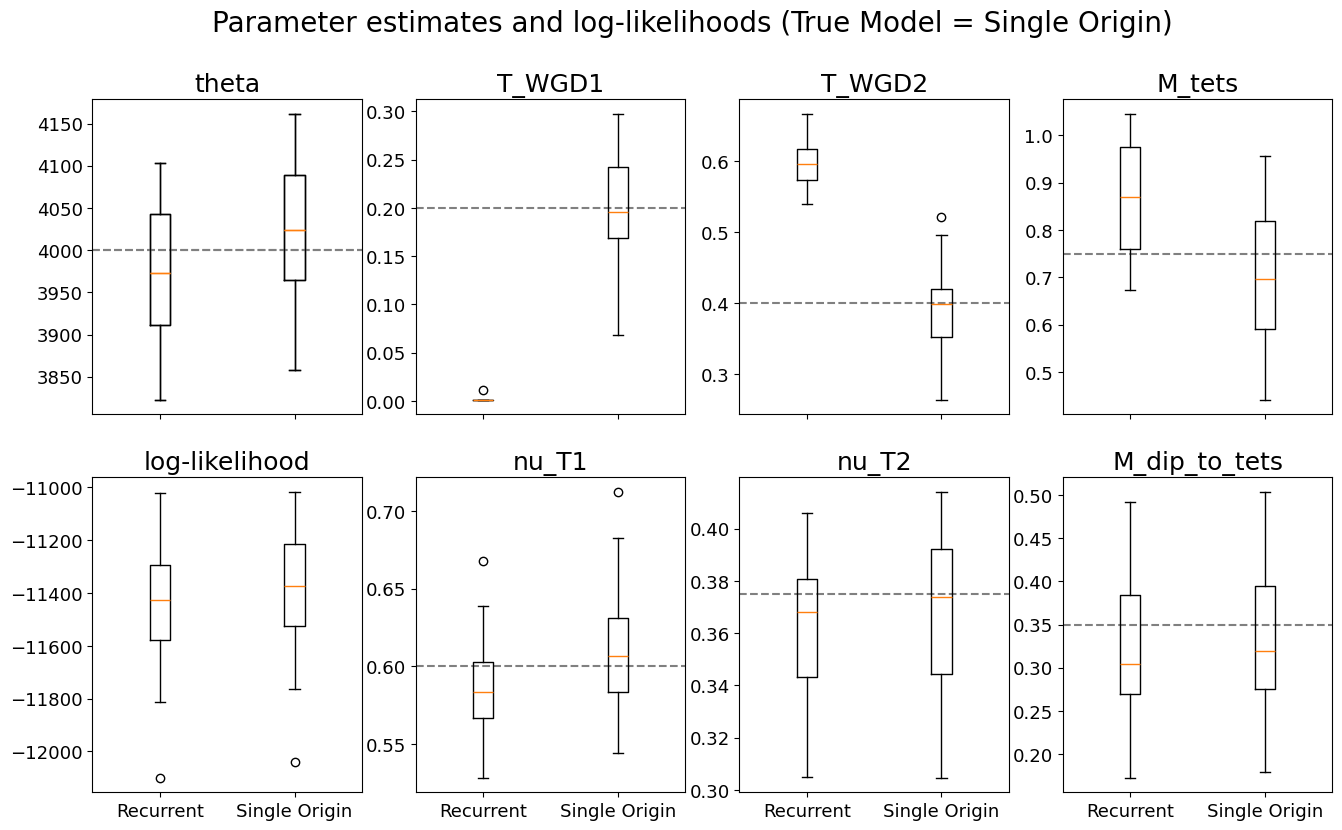

In [80]:
fig, ax = plt.subplots(2, 4, figsize=(16, 9))
fig.suptitle('Parameter estimates and log-likelihoods (True Model = Single Origin)')

plot_param_boxplots(ax[0,0], "Single Origin Data/", title="theta", param="theta")
plot_param_boxplots(ax[0,0], "Single Origin Data/", title="theta", param="theta")
plot_param_boxplots(ax[0,1], "Single Origin Data/", title="T_WGD1", param="T_WGD1")
plot_param_boxplots(ax[0,2], "Single Origin Data/", title="T_WGD2", param="T_WGD2")
plot_param_boxplots(ax[0,3], "Single Origin Data/", title="M_tets", param="M_tets")
plot_param_boxplots(ax[1,0], "Single Origin Data/", title="log-likelihood", param="log_likelihood")
plot_param_boxplots(ax[1,1], "Single Origin Data/", title="nu_T1", param="nu_T1")
plot_param_boxplots(ax[1,2], "Single Origin Data/", title="nu_T2", param="nu_T2")
plot_param_boxplots(ax[1,3], "Single Origin Data/", title="M_dip_to_tets", param="M_T_D")

for i in range(4):
    ax[1,i].set_xticks([1, 2], ['Recurrent', 'Single Origin'])

fig.savefig("single_vs_recurrent.pdf", dpi=900, format='pdf')

In [18]:
def plot_param_scatter(ax, base_path_to_data, param, true_val=None, title=None):
    """
    Plot parameter estimates from Recurrent vs Single models.
    X-axis: Single model values
    Y-axis: Recurrent model values
    """
    
    # Load the data files
    recurrent_df = pd.read_csv(base_path_to_data + "model_recurrent/best_fits.csv")
    single_df = pd.read_csv(base_path_to_data + "model_single/best_fits.csv")
    
    # Create scatter plot: x = single model, y = recurrent model
    ax.scatter(single_df[param], recurrent_df[param], alpha=0.6, color='steelblue', s=50)
    
    # Add 1:1 reference line
    min_val = min(single_df[param].min(), recurrent_df[param].min())
    max_val = max(single_df[param].max(), recurrent_df[param].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, linewidth=1)
    
    # Add true value lines (vertical and horizontal) and black point
    if true_val is not None:
        ax.axvline(true_val, color='gray', linestyle='--', alpha=0.5)
        ax.axhline(true_val, color='gray', linestyle='--', alpha=0.5)
        ax.plot(true_val, true_val, 'ko', markersize=8)
    
    ax.set_xlabel('Single Model')
    ax.set_ylabel('Recurrent Model')
    ax.set_title(title or param)

def plot_param_scatter(ax, base_path_to_data, param, true_val=None, true_model=None, title=None):
    """
    Plot parameter estimates from Recurrent vs Single models.
    X-axis: Single model values
    Y-axis: Recurrent model values
    """
    
    # Load the data files
    recurrent_df = pd.read_csv(base_path_to_data + "model_recurrent/best_fits.csv")
    single_df = pd.read_csv(base_path_to_data + "model_single/best_fits.csv")
    
    # Create scatter plot: x = single model, y = recurrent model
    ax.scatter(single_df[param], recurrent_df[param], alpha=0.6, color='steelblue', s=50)
    
    # Add 1:1 reference line
    min_val = min(single_df[param].min(), recurrent_df[param].min())
    max_val = max(single_df[param].max(), recurrent_df[param].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, linewidth=1)
    
    # Add true value lines (vertical and horizontal) and black point
    if true_val is not None:
        ax.axvline(true_val, color='gray', linestyle='--', alpha=0.5)
        ax.axhline(true_val, color='gray', linestyle='--', alpha=0.5)
        ax.plot(true_val, true_val, 'ko', markersize=8)
        
        # Count which model is closer to true value
        if true_model == 'recurrent':
            recurrent_diff = np.abs(recurrent_df[param] - true_val)
            single_diff = np.abs(single_df[param] - true_val)
            
            recurrent_closer = (recurrent_diff < single_diff).sum()
            single_closer = (single_diff < recurrent_diff).sum()
            
            # Add label on plot
            label_text = f'Recurrent closer: {recurrent_closer}'
            ax.text(0.95, 0.95, label_text, transform=ax.transAxes, 
                    verticalalignment='top', horizontalalignment='right', fontsize=12,
                    bbox=dict(boxstyle='round', facecolor='grey', alpha=0.5))
        elif true_model == 'single':
            recurrent_diff = np.abs(recurrent_df[param] - true_val)
            single_diff = np.abs(single_df[param] - true_val)
            
            recurrent_closer = (recurrent_diff < single_diff).sum()
            single_closer = (single_diff < recurrent_diff).sum()
            
            # Add label on plot
            label_text = f'{single_closer}'
            ax.text(0.95, 0.95, label_text, transform=ax.transAxes, 
                    verticalalignment='top', horizontalalignment='right', fontsize=12,
                    bbox=dict(boxstyle='round', facecolor='grey', alpha=0.5))
    
    ax.set_xlabel('Single Model')
    ax.set_ylabel('Recurrent Model')
    ax.set_title(title or param)


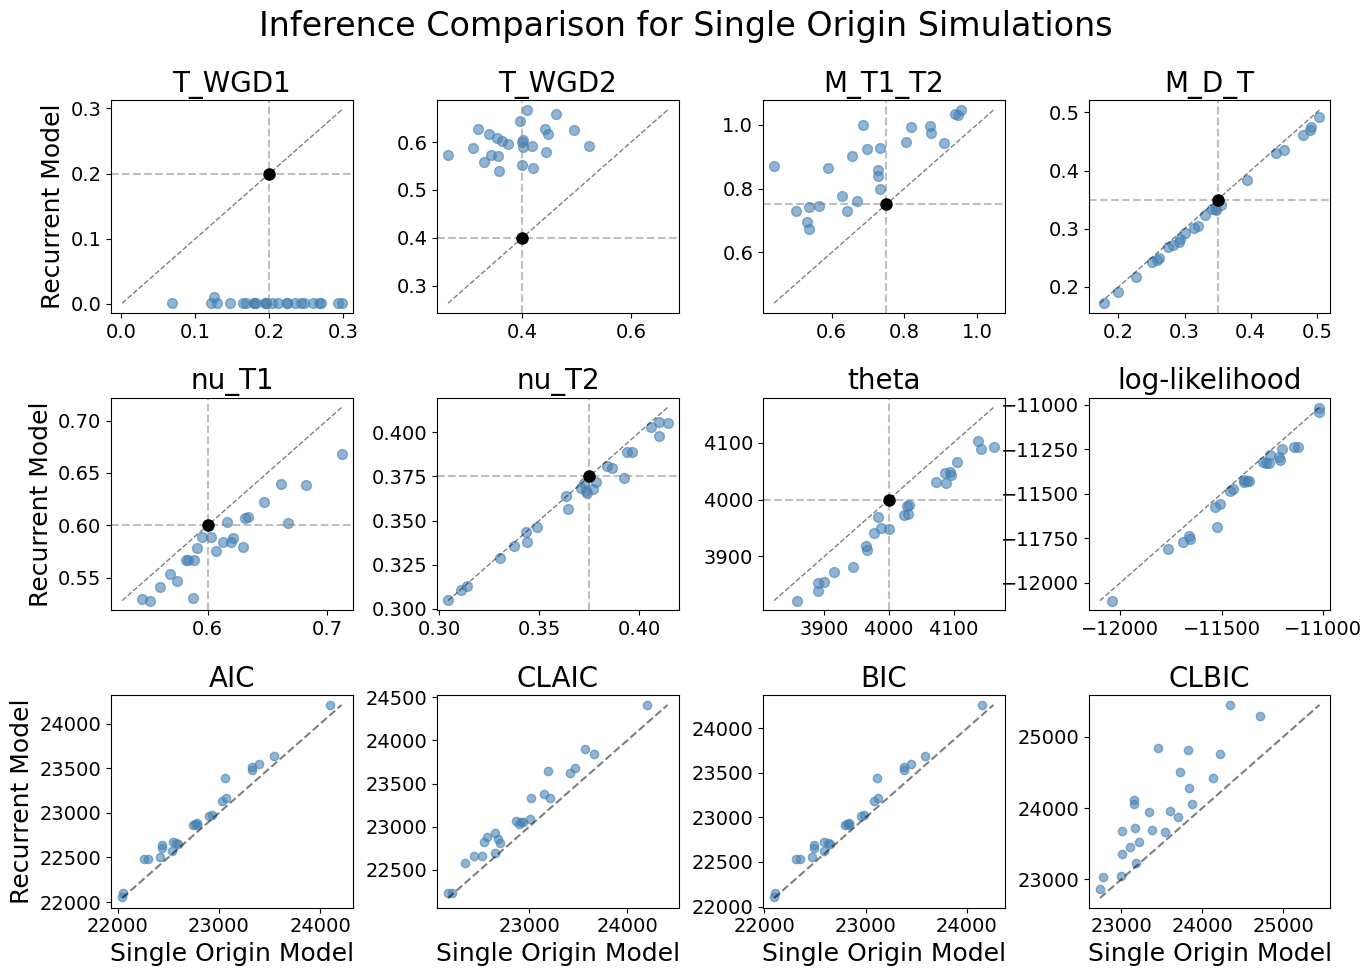

In [40]:
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
plot_param_scatter(axes[0,0], "Single Origin Data/", "T_WGD1", true_val=0.2,  title="T_WGD1")
plot_param_scatter(axes[0,1], "Single Origin Data/", "T_WGD2", true_val=0.4,  title="T_WGD2")
plot_param_scatter(axes[0,2], "Single Origin Data/", "M_tets", true_val=0.75,  title="M_T1_T2")
plot_param_scatter(axes[0,3], "Single Origin Data/", "M_T_D", true_val=0.35, title="M_D_T")
plot_param_scatter(axes[1,0], "Single Origin Data/", "nu_T1", true_val=.6, title="nu_T1")
plot_param_scatter(axes[1,1], "Single Origin Data/", "nu_T2", true_val=.375,  title="nu_T2")
plot_param_scatter(axes[1,2], "Single Origin Data/", "theta", true_val=4000,  title="theta")
plot_param_scatter(axes[1,3], "Single Origin Data/", "log_likelihood", title="log-likelihood")

for i in range(2):
    for j in range(4):
        axes[i,j].set_xlabel('')
        if j !=0:
            axes[i,j].set_ylabel('')

datasets = [("Single Origin Data/", "Single Origin Data")]
metrics = ['AIC', 'CLAIC', 'BIC', 'CLBIC']

for i, (data_path, data_label) in enumerate(datasets):
    recurrent_df = pd.read_csv(data_path + "model_recurrent/AIC_BIC.csv")
    single_df = pd.read_csv(data_path + "model_single/AIC_BIC.csv")
    
    for j, metric in enumerate(metrics):
        ax = axes[i+2, j]
        
        ax.scatter(single_df[metric], recurrent_df[metric], alpha=0.6, color='steelblue')
        ax.set_xlabel('Single Origin Model')
        
        # Add 1:1 reference line
        min_val = min(single_df[metric].min(), recurrent_df[metric].min())
        max_val = max(single_df[metric].max(), recurrent_df[metric].max())
        ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, label='')
        
        # Count how many replicates favor each model
        recurrent_wins = (recurrent_df[metric] < single_df[metric]).sum()
        single_wins = (single_df[metric] < recurrent_df[metric]).sum()
        
        if i==1:
            ax.set_xlabel('Single Origin Model')
        if i==0:
            ax.set_title(f'{metric}')
axes[2,0].set_ylabel('Recurrent Model')

fig.suptitle('Inference Comparison for Single Origin Simulations')
plt.tight_layout()
plt.subplots_adjust(hspace=0.4, wspace=0.35)
fig.savefig("single_comparison.pdf", bbox_inches='tight', format='pdf', dpi=900)


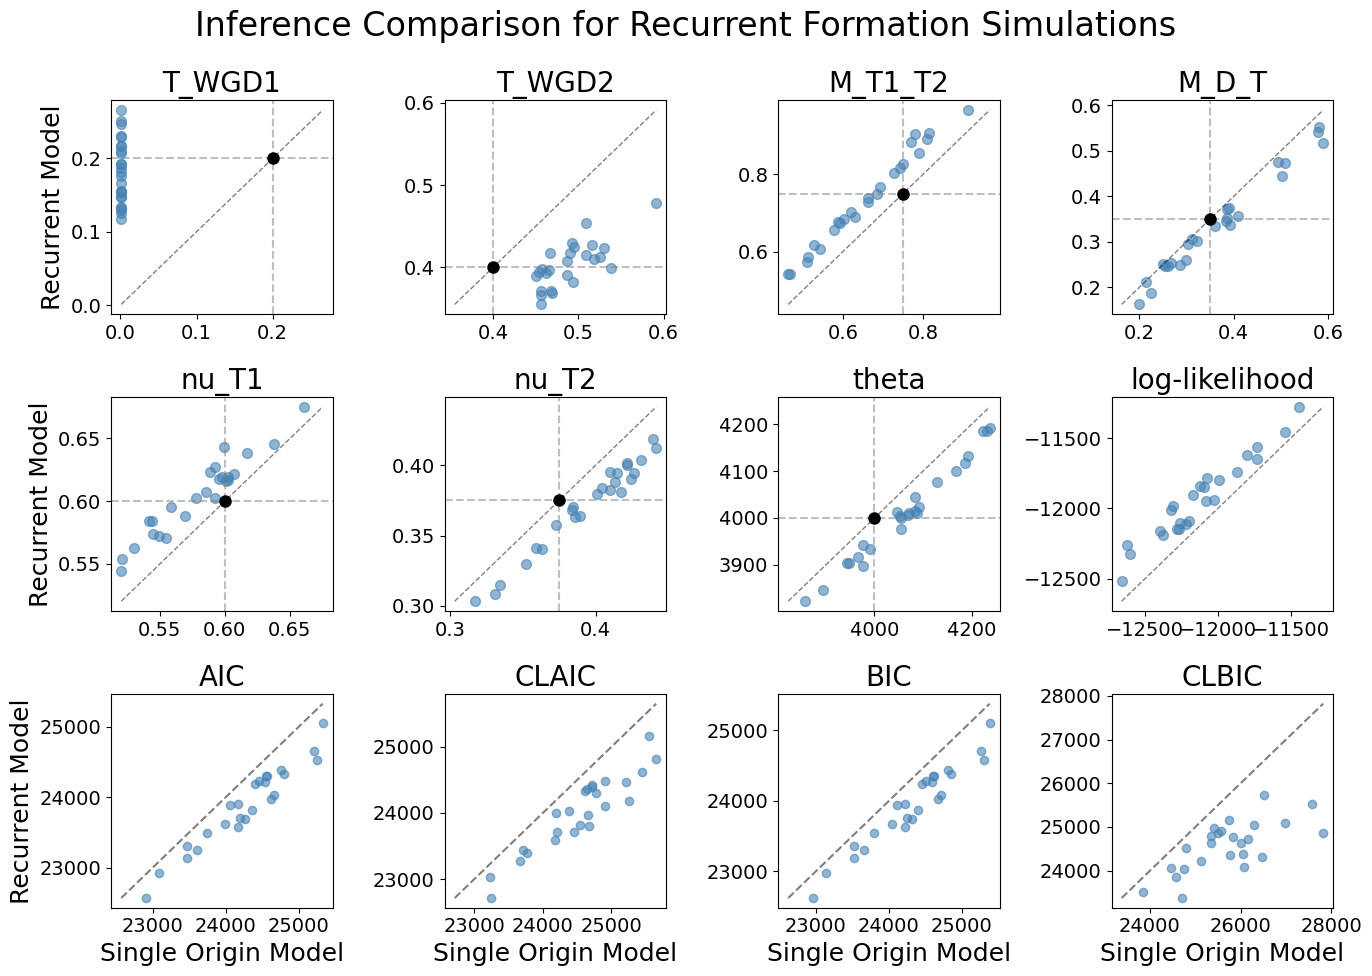

<Figure size 640x480 with 0 Axes>

In [41]:
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
plot_param_scatter(axes[0,0], "Recurrent Formation Data/", "T_WGD1", true_val=0.2, title="T_WGD1")
plot_param_scatter(axes[0,1], "Recurrent Formation Data/", "T_WGD2", true_val=0.4,  title="T_WGD2")
plot_param_scatter(axes[0,2], "Recurrent Formation Data/", "M_tets", true_val=0.75, title="M_T1_T2")
plot_param_scatter(axes[0,3], "Recurrent Formation Data/", "M_T_D", true_val=0.35, title="M_D_T")
plot_param_scatter(axes[1,0], "Recurrent Formation Data/", "nu_T1", true_val=.6,  title="nu_T1")
plot_param_scatter(axes[1,1], "Recurrent Formation Data/", "nu_T2", true_val=.375,  title="nu_T2")
plot_param_scatter(axes[1,2], "Recurrent Formation Data/", "theta", true_val=4000,  title="theta")
plot_param_scatter(axes[1,3], "Recurrent Formation Data/", "log_likelihood", title="log-likelihood")
for i in range(2):
    for j in range(4):
        axes[i,j].set_xlabel('')
        if j !=0:
            axes[i,j].set_ylabel('')
fig.suptitle('Inference Comparison for Recurrent Formation Simulations')

datasets = [("Recurrent Formation Data/", "Recurrent Formation Data")]
metrics = ['AIC', 'CLAIC', 'BIC', 'CLBIC']

for i, (data_path, data_label) in enumerate(datasets):
    recurrent_df = pd.read_csv(data_path + "model_recurrent/AIC_BIC.csv")
    single_df = pd.read_csv(data_path + "model_single/AIC_BIC.csv")
    
    for j, metric in enumerate(metrics):
        ax = axes[i+2, j]
        
        ax.scatter(single_df[metric], recurrent_df[metric], alpha=0.6, color='steelblue')
        ax.set_xlabel('Single Origin Model')
        
        # Add 1:1 reference line
        min_val = min(single_df[metric].min(), recurrent_df[metric].min())
        max_val = max(single_df[metric].max(), recurrent_df[metric].max())
        ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, label='')
        
        # Count how many replicates favor each model
        recurrent_wins = (recurrent_df[metric] < single_df[metric]).sum()
        single_wins = (single_df[metric] < recurrent_df[metric]).sum()
        
        if i==1:
            ax.set_xlabel('Single Origin Model')
        if i==0:
            ax.set_title(f'{metric}')

# Add data type labels on leftmost plots
axes[2, 0].set_ylabel('Recurrent Model')

plt.tight_layout()
plt.show()


plt.tight_layout()
plt.subplots_adjust(hspace=0.4, wspace=0.35)
fig.savefig("recurrent_comparison.pdf", bbox_inches='tight', format='pdf', dpi=900)


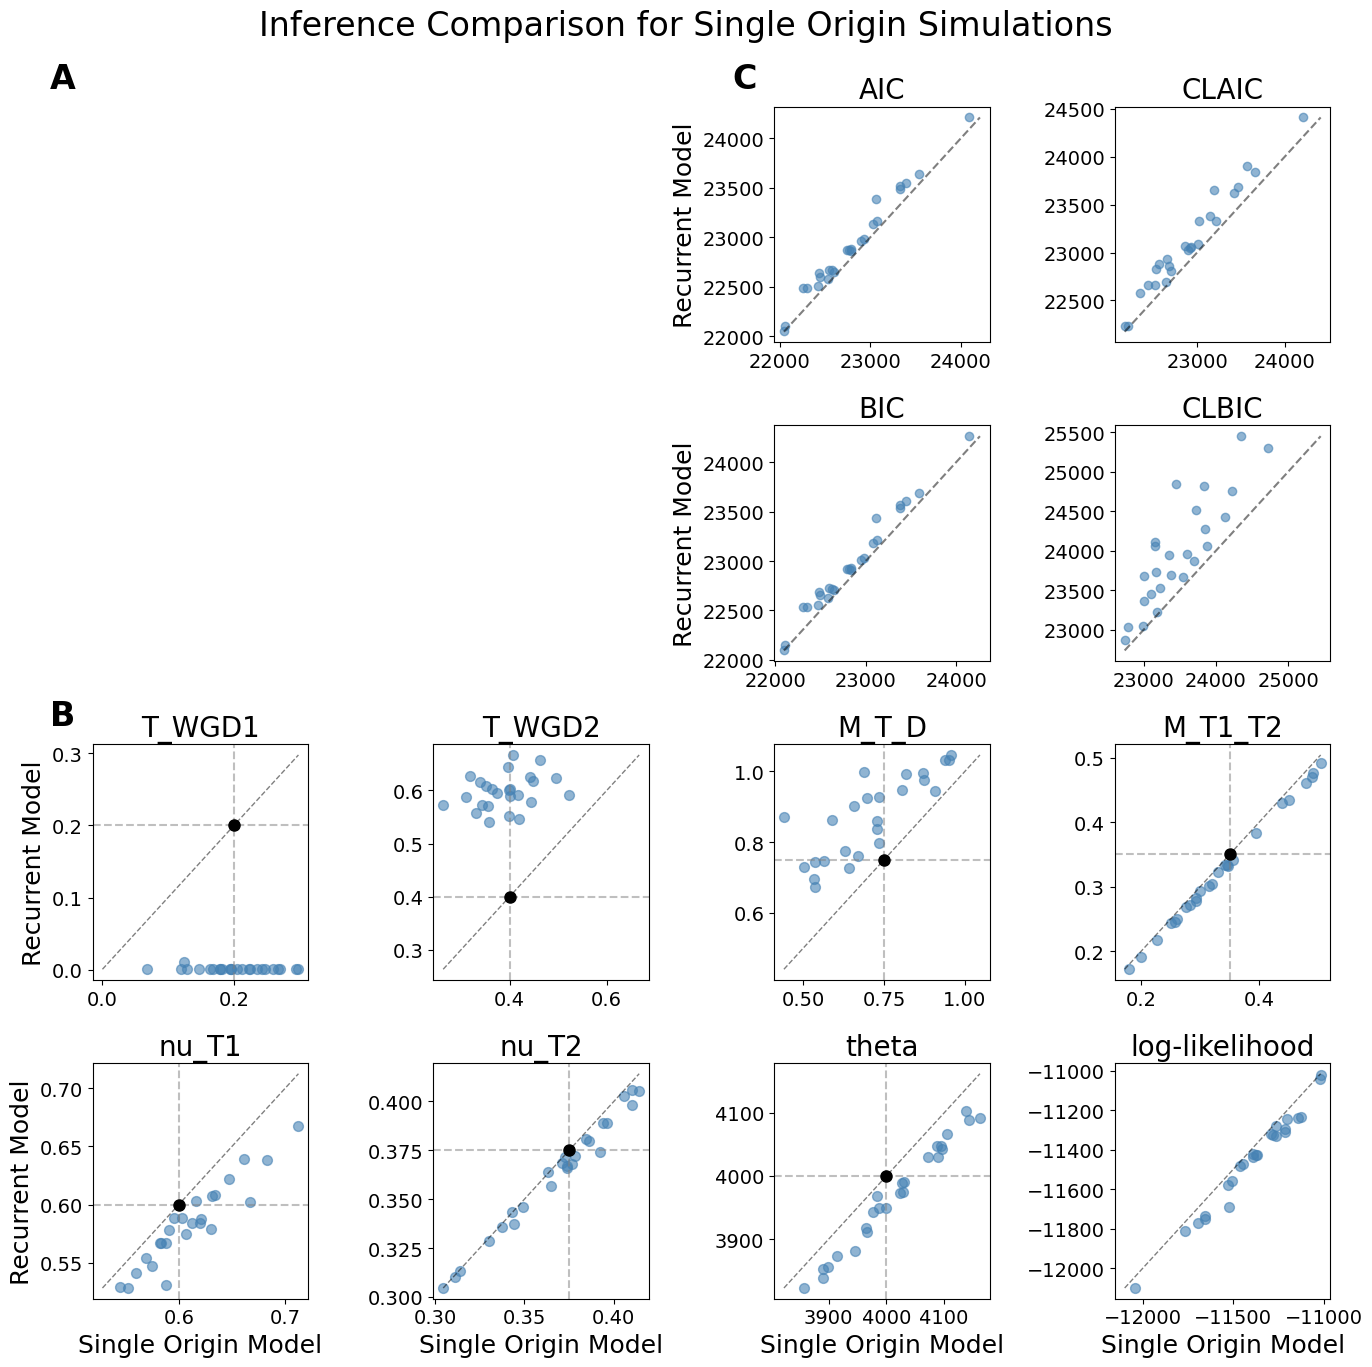

<Figure size 640x480 with 0 Axes>

In [42]:
fig, axes = plt.subplots(4, 4, figsize=(14, 14))
plot_param_scatter(axes[2,0], "Single Origin Data/", "T_WGD1", true_val=0.2, title="T_WGD1")
plot_param_scatter(axes[2,1], "Single Origin Data/", "T_WGD2", true_val=0.4,  title="T_WGD2")
plot_param_scatter(axes[2,2], "Single Origin Data/", "M_tets", true_val=0.75, title="M_T_D")
plot_param_scatter(axes[2,3], "Single Origin Data/", "M_T_D", true_val=0.35, title="M_T1_T2")
plot_param_scatter(axes[3,0], "Single Origin Data/", "nu_T1", true_val=.6,  title="nu_T1")
plot_param_scatter(axes[3,1], "Single Origin Data/", "nu_T2", true_val=.375,  title="nu_T2")
plot_param_scatter(axes[3,2], "Single Origin Data/", "theta", true_val=4000,  title="theta")
plot_param_scatter(axes[3,3], "Single Origin Data/", "log_likelihood", title="log-likelihood")
for i in range(4):
    for j in range(4):
        axes[i,j].set_xlabel('')
        if j !=0:
            axes[i,j].set_ylabel('')
fig.suptitle('Inference Comparison for Single Origin Simulations')

datasets = [("Single Origin Data/", "Single Origin Data")]
metrics = ['AIC', 'CLAIC', 'BIC', 'CLBIC']

for i, (data_path, data_label) in enumerate(datasets):
    recurrent_df = pd.read_csv(data_path + "model_recurrent/AIC_BIC.csv")
    single_df = pd.read_csv(data_path + "model_single/AIC_BIC.csv")
    
    for j, metric in enumerate(metrics):
        if j == 0:
            ax = axes[0,2]
        elif j == 1:
            ax = axes[0,3]
        elif j == 2:
            ax = axes[1,2]
        elif j == 3:
            ax = axes[1,3]
        
        ax.scatter(single_df[metric], recurrent_df[metric], alpha=0.6, color='steelblue')
        
        # Add 1:1 reference line
        min_val = min(single_df[metric].min(), recurrent_df[metric].min())
        max_val = max(single_df[metric].max(), recurrent_df[metric].max())
        ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, label='')
        
        # Count how many replicates favor each model
        recurrent_wins = (recurrent_df[metric] < single_df[metric]).sum()
        single_wins = (single_df[metric] < recurrent_df[metric]).sum()
        
        if i==0:
            ax.set_title(f'{metric}')

# Add data type labels on leftmost plots
axes[2, 0].set_ylabel('Recurrent Model')
axes[3, 0].set_ylabel('Recurrent Model')
axes[0, 2].set_ylabel('Recurrent Model')
axes[1, 2].set_ylabel('Recurrent Model')

for i in range(2):
    for j in range(2):
        axes[i,j].axis('off')

for i in range(4):
    axes[3,i].set_xlabel('Single Origin Model')

# Add subfigure labels
axes[0,0].text(-0.08, 1.05, 'A', transform=axes[0,0].transAxes,
               fontsize=24, fontweight='bold', va='bottom', ha='right')
axes[2,0].text(-0.08, 1.05, 'B', transform=axes[2,0].transAxes,
               fontsize=24, fontweight='bold', va='bottom', ha='right')
axes[0,2].text(-0.08, 1.05, 'C', transform=axes[0,2].transAxes,
               fontsize=24, fontweight='bold', va='bottom', ha='right')


plt.tight_layout()
plt.show()


plt.tight_layout()
plt.subplots_adjust(hspace=0.4, wspace=0.35)
fig.savefig("single_comparison_v2.pdf", bbox_inches='tight', format='pdf', dpi=900)

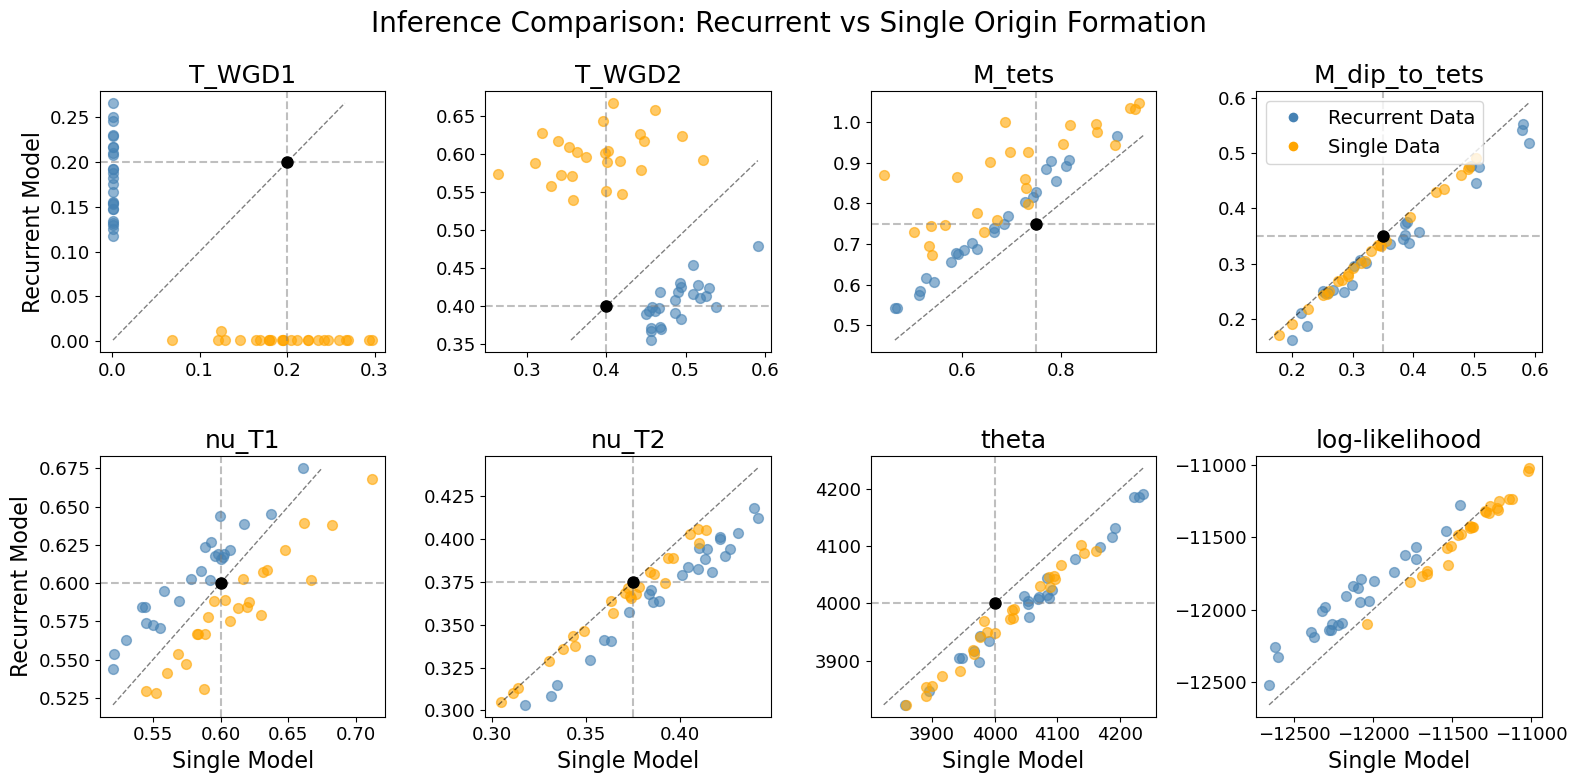

In [ ]:
def plot_param_scatter_combined(ax, base_path_to_data, param, color='steelblue'):
    """
    Plot parameter estimates with specified color.
    X-axis: Single model values
    Y-axis: Recurrent model values
    """
    recurrent_df = pd.read_csv(base_path_to_data + "model_recurrent/best_fits.csv")
    single_df = pd.read_csv(base_path_to_data + "model_single/best_fits.csv")
    
    ax.scatter(single_df[param], recurrent_df[param], alpha=0.6, color=color, s=50)

# Create the combined figure
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Parameters to plot
params_data = [
    ("T_WGD1", 0.2, "T_WGD1"),
    ("T_WGD2", 0.4, "T_WGD2"),
    ("M_tets", 0.75, "M_tets"),
    ("M_T_D", 0.35, "M_dip_to_tets"),
    ("nu_T1", 0.6, "nu_T1"),
    ("nu_T2", 0.375, "nu_T2"),
    ("theta", 4000, "theta"),
    ("log_likelihood", None, "log-likelihood")
]

# Plot both datasets on each subplot
for idx, (param, true_val, title) in enumerate(params_data):
    i, j = idx // 4, idx % 4
    ax = axes[i, j]
    
    # Plot Recurrent Formation Data in blue
    plot_param_scatter_combined(ax, "Recurrent Formation Data/", param, color='steelblue')
    
    # Plot Single Origin Data in orange
    plot_param_scatter_combined(ax, "Single Origin Data/", param, color='orange')
    
    # Add reference lines and formatting
    recurrent_df = pd.read_csv("Recurrent Formation Data/" + "model_recurrent/best_fits.csv")
    single_df = pd.read_csv("Recurrent Formation Data/" + "model_single/best_fits.csv")
    
    min_val = min(single_df[param].min(), recurrent_df[param].min())
    max_val = max(single_df[param].max(), recurrent_df[param].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, linewidth=1)
    
    if true_val is not None:
        ax.axvline(true_val, color='gray', linestyle='--', alpha=0.5)
        ax.axhline(true_val, color='gray', linestyle='--', alpha=0.5)
        ax.plot(true_val, true_val, 'ko', markersize=8)
    
    ax.set_xlabel('Single Model')
    ax.set_ylabel('Recurrent Model')
    ax.set_title(title)

# Add legend to top-right plot only
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue', markersize=8, label='Recurrent Data'),
                   Line2D([0], [0], marker='o', color='w', markerfacecolor='orange', markersize=8, label='Single Data')]
axes[0, 3].legend(handles=legend_elements, loc='best', fontsize=14)

# Adjust labels
for i in range(2):
    for j in range(4):
        if i == 0:
            axes[i,j].set_xlabel('')
        if j != 0:
            axes[i,j].set_ylabel('')



fig.suptitle('Inference Comparison: Recurrent vs Single Origin Formation')
plt.tight_layout()
plt.subplots_adjust(hspace=0.4, wspace=0.35)
plt.show()
fig.savefig("recurrent_and_single.pdf", bbox_inches='tight', format='pdf', dpi=900)


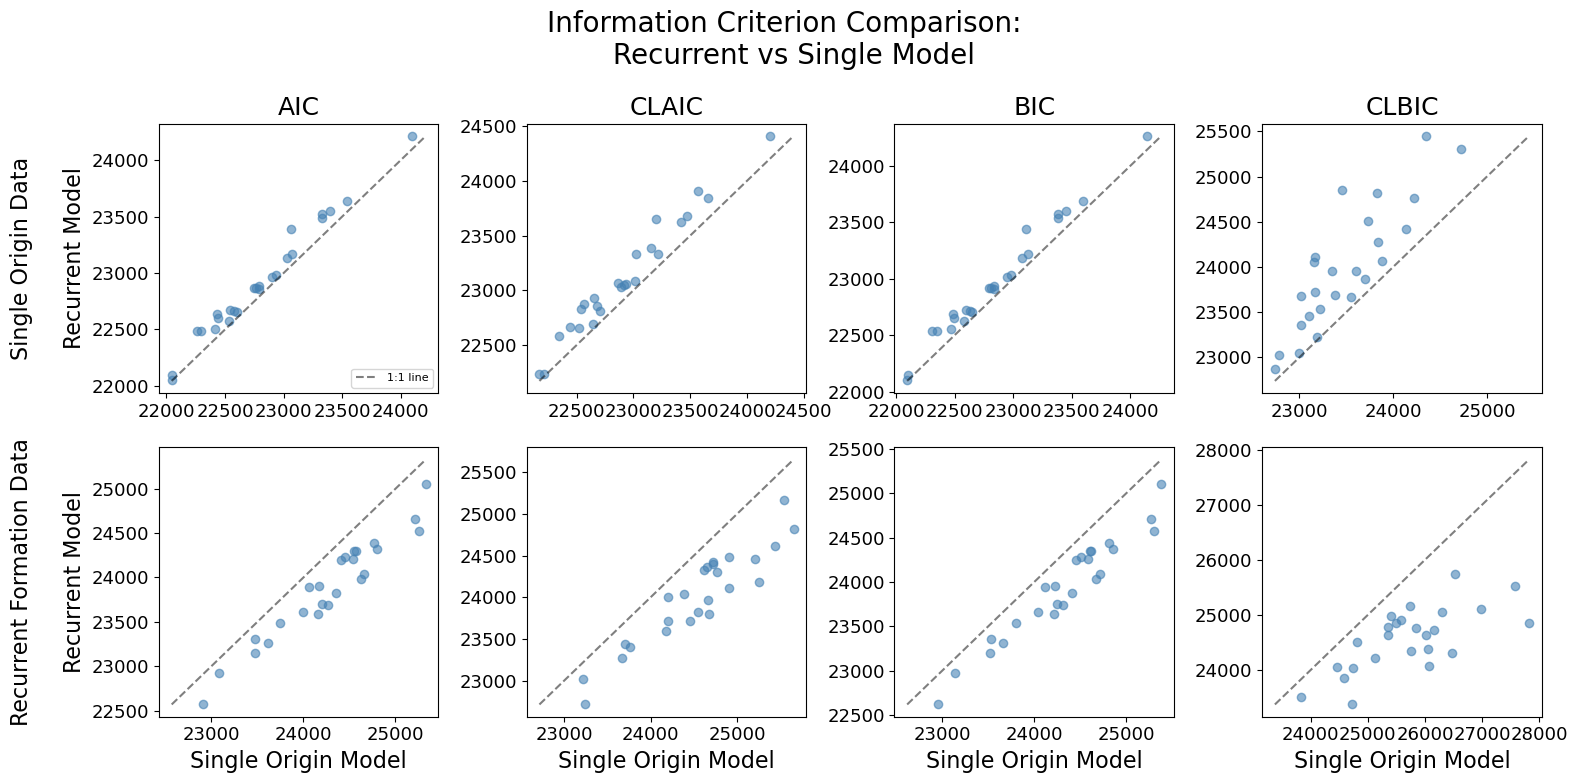

In [16]:
# Plot model comparisons: Recurrent Model vs Single Model for each metric
# Points below the 1:1 line favor the Recurrent Model (lower = better fit)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Information Criterion Comparison: \n Recurrent vs Single Model')

datasets = [
    ("Single Origin Data/", "Single Origin Data"),
    ("Recurrent Formation Data/", "Recurrent Formation Data")
]
metrics = ['AIC', 'CLAIC', 'BIC', 'CLBIC']

for i, (data_path, data_label) in enumerate(datasets):
    recurrent_df = pd.read_csv(data_path + "model_recurrent/AIC_BIC.csv")
    single_df = pd.read_csv(data_path + "model_single/AIC_BIC.csv")
    
    for j, metric in enumerate(metrics):
        ax = axes[i, j]
        
        ax.scatter(single_df[metric], recurrent_df[metric], alpha=0.6, color='steelblue')
        
        # Add 1:1 reference line
        min_val = min(single_df[metric].min(), recurrent_df[metric].min())
        max_val = max(single_df[metric].max(), recurrent_df[metric].max())
        ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, label='1:1 line')
        
        # Count how many replicates favor each model
        recurrent_wins = (recurrent_df[metric] < single_df[metric]).sum()
        single_wins = (single_df[metric] < recurrent_df[metric]).sum()
        
        if i==1:
            ax.set_xlabel('Single Origin Model')
        if i==0:
            ax.set_title(f'{metric}')
        if i==0 and j==0:
            ax.legend(loc='lower right', fontsize=8)

# Add data type labels on leftmost plots
axes[0, 0].set_ylabel('Single Origin Data\n\nRecurrent Model')
axes[1, 0].set_ylabel('Recurrent Formation Data\n\nRecurrent Model')

plt.tight_layout()
plt.show()

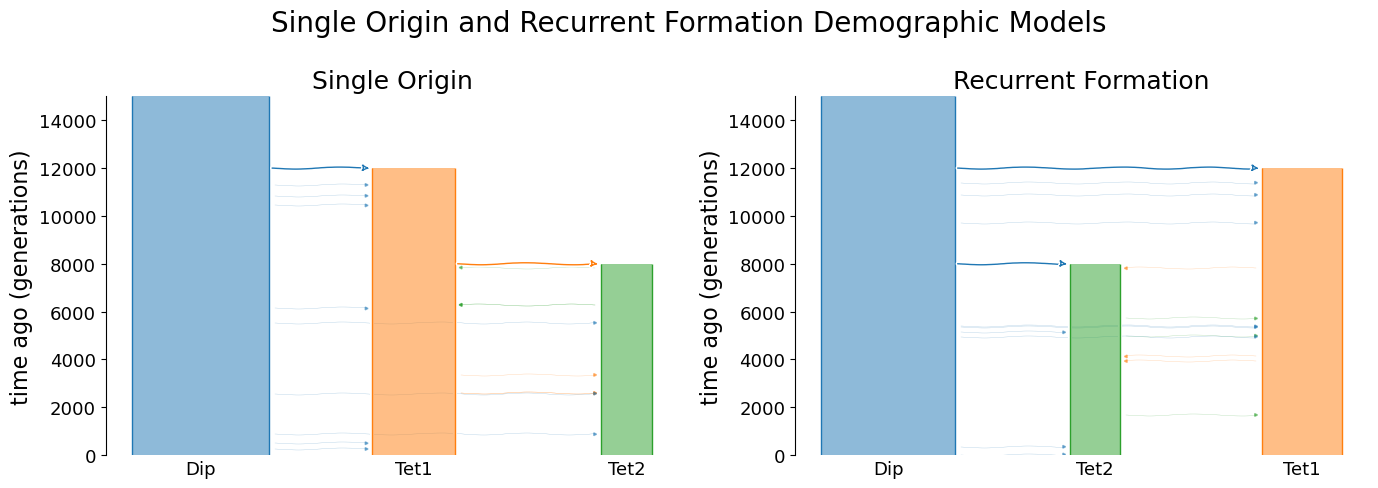

In [121]:
g_r = demes.load('recurrent.yaml')
g_s = demes.load('single_origin.yaml')

# Plot the two demes
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Single Origin and Recurrent Formation Demographic Models')

demesdraw.tubes(g_s, ax=ax[0], title='Single Origin', num_lines_per_migration=3)
demesdraw.tubes(g_r, ax=ax[1], title='Recurrent Formation', num_lines_per_migration=3)
plt.tight_layout()




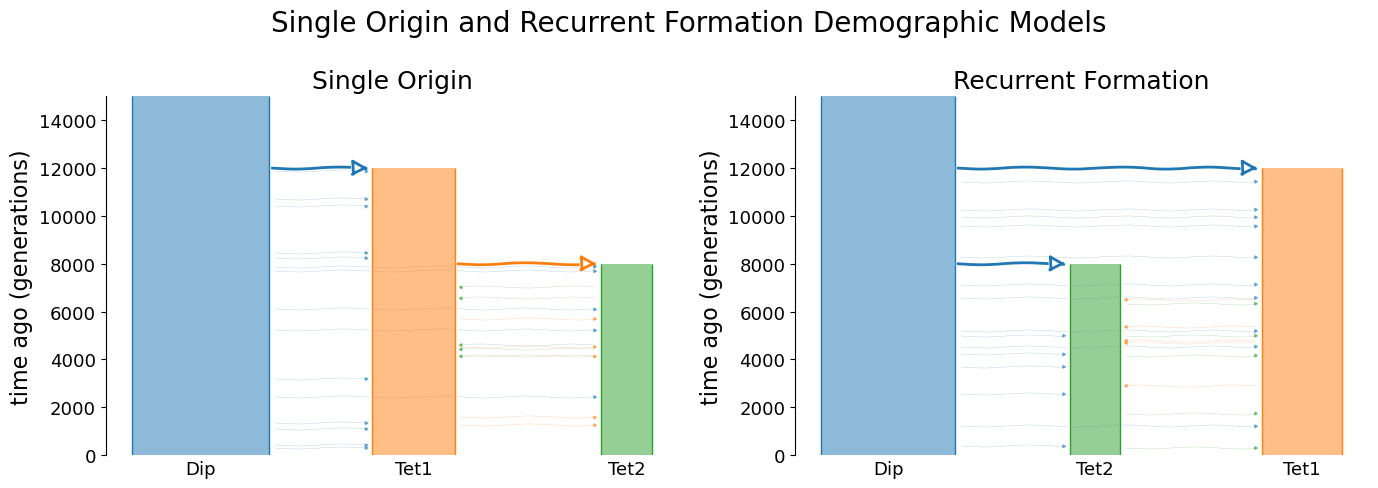

In [12]:
g_r = demes.load('recurrent.yaml')
g_s = demes.load('single_origin.yaml')

# Plot the two demes
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Single Origin and Recurrent Formation Demographic Models')

demesdraw.tubes(g_s, ax=ax[0], title='Single Origin', num_lines_per_migration=5)
demesdraw.tubes(g_r, ax=ax[1], title='Recurrent Formation', num_lines_per_migration=5)

for axes in ax:
    for patch in axes.patches:
        if hasattr(patch, 'get_arrowstyle'): 
            patch.set_mutation_scale(25)
            patch.set_linewidth(2)


plt.tight_layout()
fig.savefig('single_recurrent_demes.pdf', bbox_inches='tight', format='pdf', dpi=900)



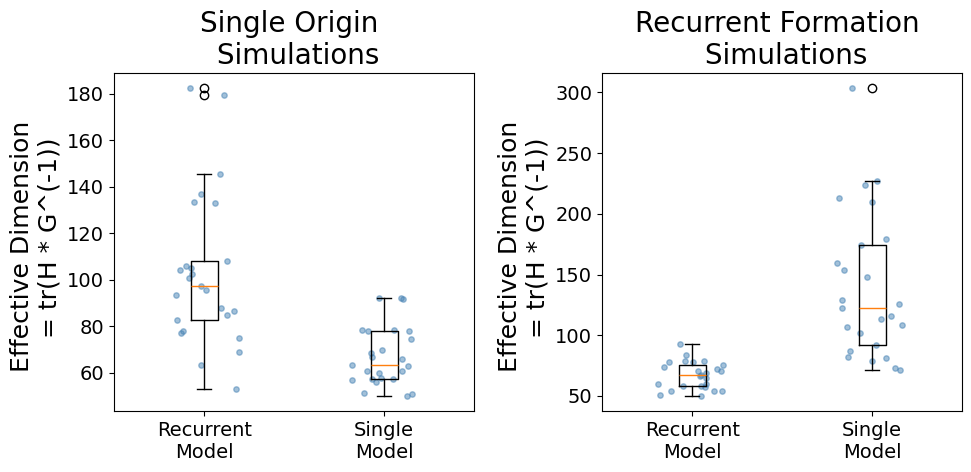

In [49]:
# Plot effective dimension for each model and data type
# Effective dimension = (CLAIC + 2 * log_likelihood) / 2

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

datasets = [
    ("Single Origin Data/", "Single Origin \n Simulations"),
    ("Recurrent Formation Data/", "Recurrent Formation \n Simulations")
]

for ax, (data_path, data_label) in zip(axes, datasets):
    recurrent_df = pd.read_csv(data_path + "model_recurrent/AIC_BIC.csv")
    single_df = pd.read_csv(data_path + "model_single/AIC_BIC.csv")

    recurrent_eff_dim = (recurrent_df['CLAIC'] + 2 * recurrent_df['ll']) / 2
    single_eff_dim = (single_df['CLAIC'] + 2 * single_df['ll']) / 2

    data = [recurrent_eff_dim, single_eff_dim]

    ax.boxplot(data)
    ax.set_xticks([1, 2], ['Recurrent\nModel', 'Single\nModel'])
    ax.set_title(data_label)
    ax.set_ylabel('Effective Dimension \n = tr(H * G^(-1))')

    for i, d in enumerate(data):
        jitter = np.random.uniform(-0.2, 0.2, size=len(d))
        ax.scatter(np.ones(len(d)) * (i + 1) + jitter, d, alpha=0.5, s=15, color='steelblue')

plt.tight_layout()
plt.show()

fig.savefig("effective_dimensions.pdf", bbox_inches='tight', format='pdf', dpi=900)